In [15]:
import numpy as np

np.random.seed(42)

T = 500
print(f"T:{T}\n")

rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])
print(f"rho: {rho}\n sigma:{sigma}\n")

P = np.array(
    [[0.95, 0.05],
    [0.05, 0.95]]
    )
print(f"P: {P}\n")

states = np.zeros(T, dtype=int)
y = np.zeros(T)
# print(f"states: {states}\n y: {y}\n")

states[0] = np.random.choice([0,1])
y[0] = np.random.normal()
print(f"states[0]: {states[0]}\n y[0]: {y[0]}\n")

for t in range(1, T):
    states[t] = np.random.choice([0,1], p=P[states[t-1]])
    s = states[t]
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

    if t % 50 == 0:
        col1 = f"iteration {t}"
        col2 = f"state: {s}"
        col3 = f"y[{t}]: {y[t]:.4f}"
        print(f"{col1:<20s}{col2:<15s}{col3}")


T:500

rho: [0.2 0.8]
 sigma:[0.5 1. ]

P: [[0.95 0.05]
 [0.05 0.95]]

states[0]: 0
 y[0]: -0.5502344891639495

iteration 50        state: 0       y[50]: -0.1451
iteration 100       state: 1       y[100]: 2.1131
iteration 150       state: 0       y[150]: 1.6434
iteration 200       state: 1       y[200]: 0.6728
iteration 250       state: 1       y[250]: 0.5355
iteration 300       state: 0       y[300]: 0.0844
iteration 350       state: 0       y[350]: 0.4408
iteration 400       state: 1       y[400]: 1.8351
iteration 450       state: 0       y[450]: -0.3329


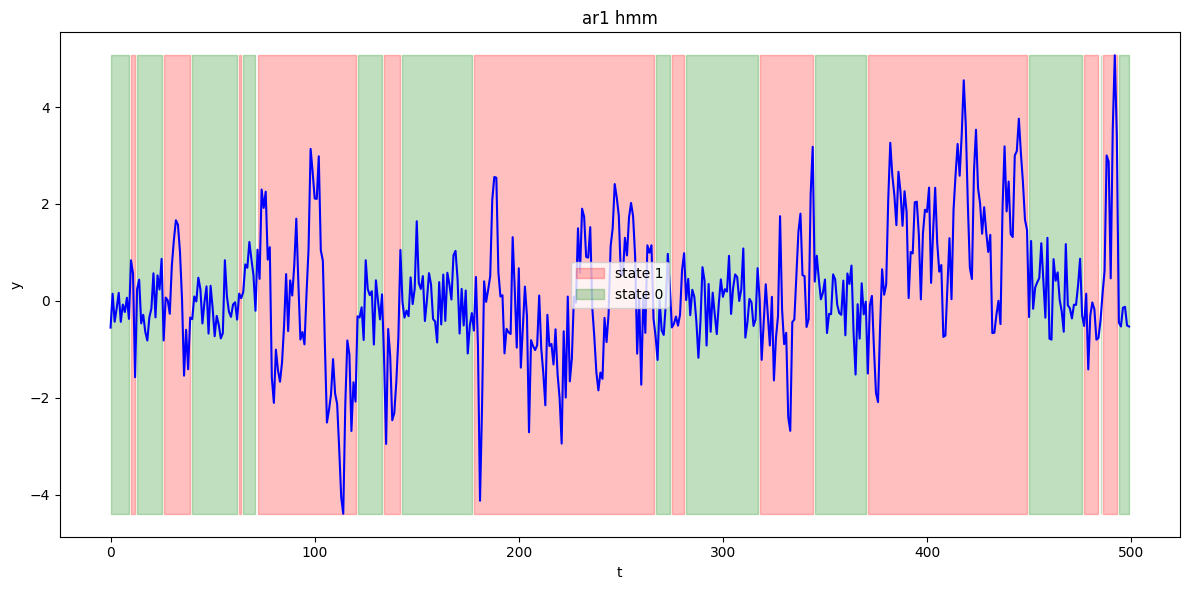

In [21]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,6))
plt.plot(y, color="blue")
plt.fill_between(range(T), y.min(), y.max(), where=(states==1), alpha=0.25, color="red", label="state 1")
plt.fill_between(range(T), y.min(), y.max(), where=(states==0), alpha=0.25, color="green", label="state 0")
plt.title("ar1 hmm")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()